# Tarefa 1: Árvores de Decisão

**Curso:** FT108A — Introdução ao Aprendizado de Máquina, 2026S2.

Este relatório aplica uma árvore de decisão ao conjunto Wine (178 amostras, 3 classes). O texto é sucinto. Os experimentos ocupam as seções 3 e 4.


## 1. Ferramenta e algoritmo

A ferramenta é o scikit-learn (PEDREGOSA et al., 2011), executado em um notebook Jupyter. O algoritmo é `DecisionTreeClassifier` com `criterion="entropy"`.

Essa implementação segue CART: cada teste é binário (HAN; KAMBER, 2006). O critério de entropia calcula o ganho de informação, a métrica que a aula detalhou para o ID3 (QUINLAN, 1986). Não há poda. O enunciado não pede esse passo.


## 2. Dados e partição

O conjunto Wine vem do repositório UCI (AEBERHARD; FORINA, 1991). Há 13 atributos químicos contínuos e o cultivar (classes 1, 2 e 3). O arquivo `wine.csv` está no mesmo diretório deste notebook.

Cada experimento separa 80% das amostras para treino e 20% para teste. A escolha é aleatória e estratificada (`stratify`), para o teste conter as três classes. As sementes das partições são 42 e 7. O classificador usa `random_state=0` nos dois casos, para isolar o efeito da partição.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

DATA_PATH = Path("wine.csv")
TARGET = "cultivar"

data = pd.read_csv(DATA_PATH)
features = data.drop(columns=[TARGET])
labels = data[TARGET]


def run_experiment(split_seed: int):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.2,
        random_state=split_seed,
        stratify=labels,
    )
    tree = DecisionTreeClassifier(criterion="entropy", random_state=0)
    tree.fit(x_train, y_train)
    train_error = 1.0 - accuracy_score(y_train, tree.predict(x_train))
    test_error = 1.0 - accuracy_score(y_test, tree.predict(x_test))
    test_classes = sorted(int(c) for c in y_test.unique())
    return tree, train_error, test_error, test_classes, len(x_train), len(x_test)


def show_tree(tree):
    fig, ax = plt.subplots(figsize=(12, 7))
    plot_tree(
        tree,
        feature_names=list(features.columns),
        class_names=["1", "2", "3"],
        filled=True,
        rounded=True,
        fontsize=7,
        ax=ax,
    )
    fig.tight_layout()
    plt.show()

## 3. Experimento 1

Partição com `random_state=42`. A figura mostra a árvore obtida. Os erros de classificação são 1 menos a acurácia.


treino: 142 amostras; teste: 36 amostras
classes no teste: [1, 2, 3]
erro de classificação no treino: 0.0000
erro de classificação no teste: 0.0278


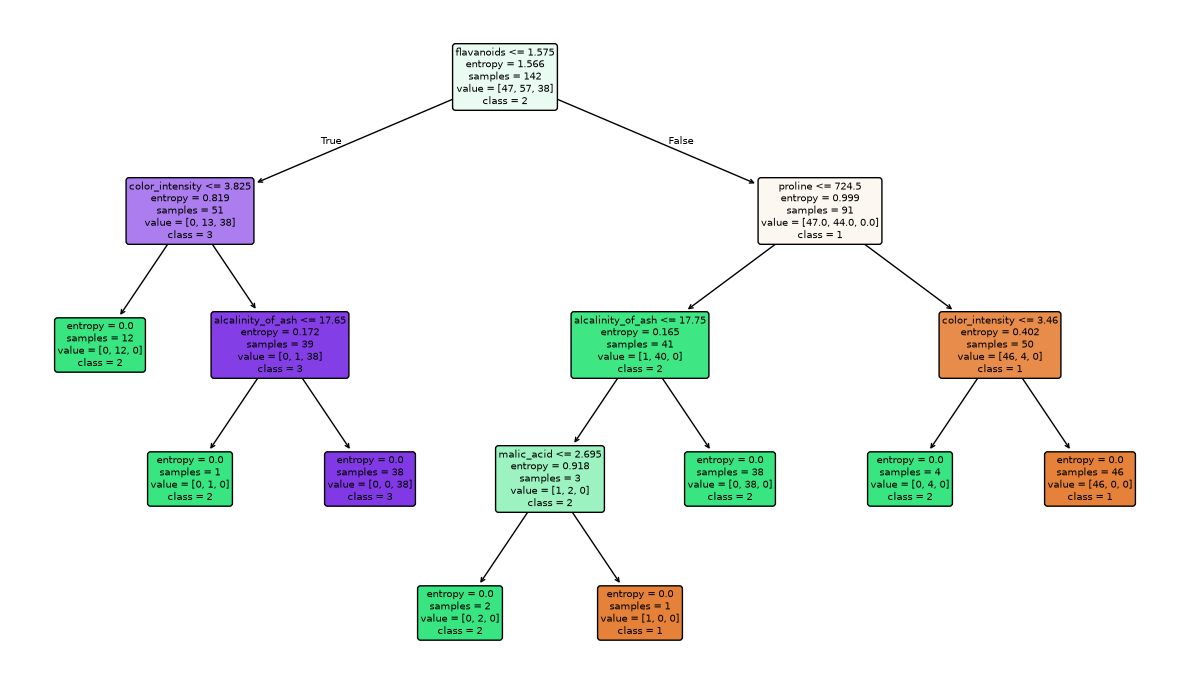

In [2]:
tree_1, train_err_1, test_err_1, test_classes_1, n_train_1, n_test_1 = run_experiment(
    42
)
print(f"treino: {n_train_1} amostras; teste: {n_test_1} amostras")
print("classes no teste:", test_classes_1)
print(f"erro de classificação no treino: {train_err_1:.4f}")
print(f"erro de classificação no teste: {test_err_1:.4f}")
show_tree(tree_1)

## 4. Experimento 2

Nova partição, com `random_state=7`. O restante do procedimento é o mesmo.


treino: 142 amostras; teste: 36 amostras
classes no teste: [1, 2, 3]
erro de classificação no treino: 0.0000
erro de classificação no teste: 0.0556


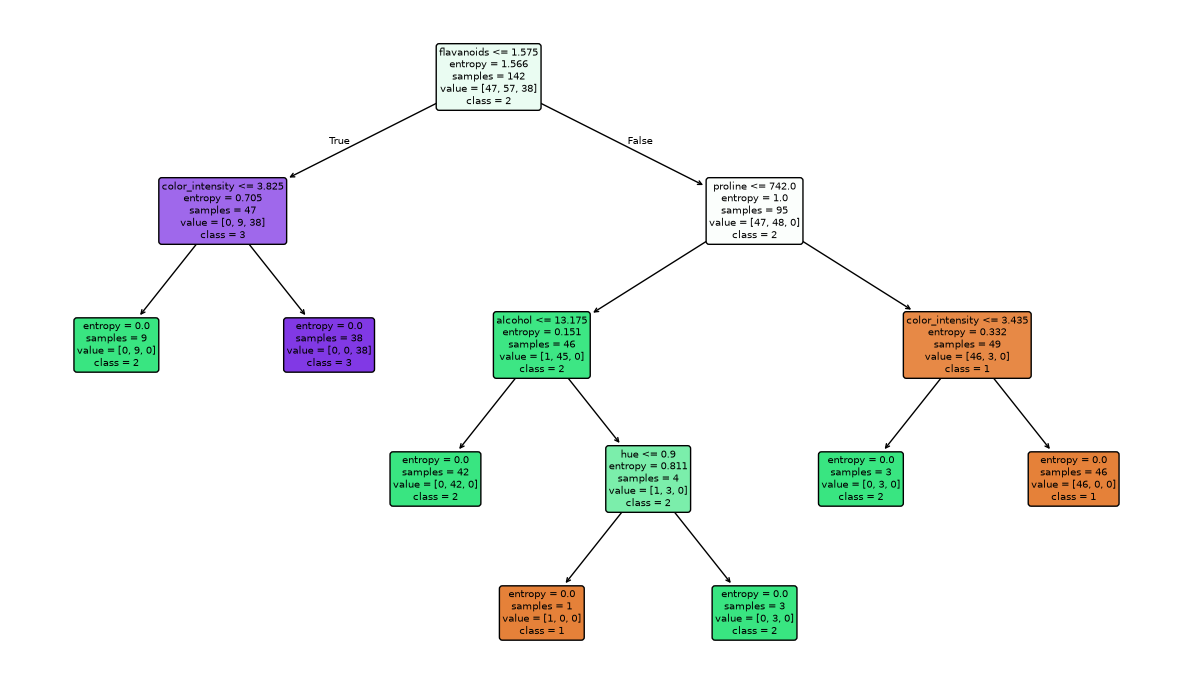

In [3]:
tree_2, train_err_2, test_err_2, test_classes_2, n_train_2, n_test_2 = run_experiment(7)
print(f"treino: {n_train_2} amostras; teste: {n_test_2} amostras")
print("classes no teste:", test_classes_2)
print(f"erro de classificação no treino: {train_err_2:.4f}")
print(f"erro de classificação no teste: {test_err_2:.4f}")
show_tree(tree_2)

## 5. Os erros foram idênticos?

Não. A partição muda o conjunto de treino, então a indução gulosa escolhe outros cortes. O conjunto de teste também muda. Com cerca de 36 amostras de teste, a estimativa de erro oscila.

Isso é o que a aula descreveu na estimativa de desempenho: um único split 80/20 não é estável. A recomendação da aula é repetir o experimento e olhar o desempenho médio.


## 6. Diferenças entre a ferramenta e a aula

A aula apresentou ID3, CART e C4.5 como processos gulosos, recursivos e top-down (HAN; KAMBER, 2006). O conteúdo calculado em sala foi o ganho de informação do ID3 (QUINLAN, 1986). Razão de ganho e índice de Gini ficaram como leitura em Han e Kamber (2006). O scikit-learn documenta a implementação usada aqui (PEDREGOSA et al., 2011).

O Wine tem só atributos contínuos. Para esse tipo, a aula já indica um teste binário: $A \leq$ ponto de corte e $A >$ ponto de corte. O atributo permanece na lista, porque outro corte pode ser útil. O CART do scikit-learn faz exatamente esse tipo de teste em todo nó.

As diferenças relevantes para este experimento são:

- **Forma da árvore.** O ID3 clássico abre um ramo por valor discreto e remove o atributo. CART é sempre binário e pode reutilizar o mesmo atributo.
- **Métrica.** A aula ensinou ganho de informação. O scikit-learn usa Gini por padrão. Este relatório força `entropy`, que é o ganho de informação. Não usa razão de ganho (C4.5).
- **Viés do ganho.** A aula mostrou que o ganho de informação favorece testes com muitas partições. CART reduz esse efeito, porque cada nó tem só duas arestas.
- **Poda.** A aula descreveu pré-poda e pós-poda. Este experimento não poda. O scikit-learn pode podar depois com cost-complexity (`ccp_alpha`). Esse critério não é o da pós-poda do C4.5.

Na prática, o modelo da ferramenta é um CART com entropia, não um ID3 de atributos discretos.


## Referências

AEBERHARD, S.; FORINA, M. Wine. Irvine: UCI Machine Learning Repository, 1991. DOI: 10.24432/C5PC7J. Disponível em: https://archive.ics.uci.edu/dataset/109/wine. Acesso em: 18 ago. 2026.

HAN, J.; KAMBER, M. Data mining: concepts and techniques. Amsterdam: Elsevier, 2006.

PEDREGOSA, F. et al. Scikit-learn: machine learning in Python. Journal of Machine Learning Research, [s. l.], v. 12, p. 2825-2830, 2011.

QUINLAN, J. R. Induction of decision trees. Machine Learning, [s. l.], v. 1, p. 81-106, 1986.

*Conteúdo, experimentos e conclusões são meus; a formatação do texto teve assistência de IA.*
